<a href="https://colab.research.google.com/github/Renata-Bilotti/Hackatho-Grupo-4/blob/main/Hacathon_Grupo_4_Mercado_de_Alfalfa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Hacathon: Comercio Internacional de Alfalfa y oportunidades comerciales para Argentina**

**Objetivo**: El siguente trabajo final busca caracterizar el mercado internacional de alfalfa y analizar la posición de Argentina dentro de ese mercado, tanto como exportados como en relación a la demanda mundial de importaciones.

A partir de ese diagónstico se buscará identificar oportunidades comerciales:
*   Identificar oportunidades comerciales: mercados grandes que hoy no están siendo suficientemente atendidos por las exportaciones argentinas.
*   Entrenar un modelo re gresión lineal múltiple para predecir el precio de exportación de la alfalfa, evaluando si la estación del año o alguna otra variable influye de forma significativa.

La base de datos contará con 4 df que se analizarán primero por separado y luego se cruzarán a fin de obtener los objetivos planteados. Debajo, luego de cargar cada df se realizará una breve explicación de cada uno de los df que se analizarán

###**Resumen de lo realizado:**

*   Análisis Exploratorio de Datos (EDA): Primero se realizarán análisis exploratorios clásicos para conocer las características de cada df y se explorarán cada variable de los df a fin de conocer la base de datos. Posteriormente se realizará un EDA del mercado mudial y la posición de Argentina, estructura del mercado exportador argentino, destino y cruce con la demanda mundial para detectar oportunidades.
*   Preprocesamiento: construcción del precio por kilogramo, tratamiento de outliers y creación de la variable estación.
*   Análisis de correlación entre variables numéricas.
*   Modelo: Regresión Lineal Múltiple, se probarán diferents modelos (statsmodels, sklearn y Catboots), con evaluación de métricas y de los supuestos del modelo (residuos).





#1. Carga de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
import statsmodels.stats.api as smf
from statsmodels.compat import lzip
from scipy.stats import shapiro


#2. Carga de Datos

El archivo es de tipo excel, el cual contiene 4 hojas: dos con alcance mundial (Impotación y Exportación Comtrade) y dos con el detalle de Argentina (Importación y Exportación Softrade).

In [ ]:
#Subida de archivo de forma manual, desde los archivos presentes en la computadora
#(El excel se encuentra disponible en Github para su descarga)

from google.colab import files
uploaded = files.upload()

Saving TradeData- alfalfa - definitiva.xlsx to TradeData- alfalfa - definitiva (1).xlsx


Debido a que la base de datos se encuentra dividida en 4 hojas, se crearán 4 datafame, que se analizarán por separado en el EDA y posteriormente se cruzarán para contestar a los objetivos del trabajo.

Aclaraciones:
1. Exportaciones mundiales: df_expo_mundo
2. Importaciones mundiales: df_impo_mundo
3. Exportaciones Argentinas: df_expo_arg
4. Detalle de importaciones por empresa: df_impo_empresa

In [ ]:
#Para evitar errores se le asigna FILENAME al nombre completo del archivo, ya que es
#extenso y con muchos espacios

FILENAME = 'TradeData- alfalfa - definitiva.xlsx'

df_expo_mundo = pd.read_excel(FILENAME, sheet_name = 'EXPO_Comtrade') #Exportaciones mundiales por país y por año
df_impo_mundo = pd.read_excel(FILENAME, sheet_name = 'IMPO_Comtrade') #Importaciones mundiales por país y por año
df_expo_arg = pd.read_excel(FILENAME, sheet_name = 'EXPO ARG_detalle_Softrade') #Detalle de exportaciones argentinas
df_impo_empresa = pd.read_excel(FILENAME, sheet_name = 'IMPO_empresa_Softrade') #Importaciones mundiales por empresa



In [ ]:
#Corroboración de la correcta subida de los df
#Exportaciones mundiales
df_expo_mundo.head()


,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20240101,2024,52,2024,32,ARG,Argentina,X,...,4.482024e+06,False,0.000,False,NaN,3456513.000,3456513.000,0,False,True
1,C,A,20240101,2024,52,2024,36,AUS,Australia,X,...,1.064254e+07,False,10642.529,False,NaN,4040253.087,4040253.087,0,False,True
2,C,A,20240101,2024,52,2024,40,AUT,Austria,X,...,1.090633e+06,False,0.000,False,NaN,376431.359,376431.359,0,False,True
3,C,A,20240101,2024,52,2024,48,BHR,Bahrain,X,...,8.600000e+03,False,0.000,False,NaN,1277.660,1277.660,0,False,True
4,C,A,20240101,2024,52,2024,56,BEL,Belgium,X,...,1.530182e+06,True,0.000,False,NaN,582970.848,582970.848,6,False,True


In [ ]:
#Corroboración de la correcta subida de los df
#Importaciones mundiales
df_impo_mundo.head()


,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20240101,2024,52,2024,24,AGO,Angola,M,...,2730.00,False,0.0,False,1053.410,NaN,1053.410,0,False,True
1,C,A,20240101,2024,52,2024,28,ATG,Antigua and Barbuda,M,...,653.76,False,0.0,False,645.996,NaN,645.996,0,False,True
2,C,A,20240101,2024,52,2024,32,ARG,Argentina,M,...,7425.00,False,0.0,False,1740.500,1039.500,1740.500,0,False,True
3,C,A,20240101,2024,52,2024,36,AUS,Australia,M,...,640.20,False,0.0,False,5697.347,5245.955,5697.347,0,False,True
4,C,A,20240101,2024,52,2024,40,AUT,Austria,M,...,10770632.00,False,0.0,False,3280935.463,NaN,3280935.463,0,False,True


In [ ]:
#Corroboración de la correcta subida de los df
#Exportaciones argentinas
df_expo_arg.head()



,Identificador,Item,Fecha,Estado,NCM-SIM,Exportador,Localidad,Tipo de Dato,Fecha Cumplido,Fecha Cargado,...,Marca - Sufijos,Cantidad.1,Unitario Divisa,FOB Divisa,Moneda Divisa,Condición de Venta,Marca o Descripcion,Descripcion Arancelaria,ES CÓRDOBA?,ES CLÚSTER?
0,24083EC01000004A,1,2024-01-02,CANC,1214.10.00.000F,LA CHITA SRL,SAN LUIS,DEFINITIVO,02/01/2024,No disponible,...,`,27.0,180.00,4860.00,DOLAR USA,FCA,`,HARINA Y PELLETS DE ALFALFA,NO,NO
1,24083EC01000005B,1,2024-01-02,CANC,1214.10.00.000F,LA CHITA SRL,SAN LUIS,DEFINITIVO,02/01/2024,No disponible,...,`,27.0,180.00,4860.00,DOLAR USA,FCA,`,HARINA Y PELLETS DE ALFALFA,NO,NO
2,24016EC01000011R,1,2024-01-03,CANC,1214.10.00.000F,ALFABAN S.R.L.,TRANSITO,DEFINITIVO,03/01/2024,No disponible,...,`,28.0,225.00,6300.00,DOLAR USA,FCA,`,HARINA Y PELLETS DE ALFALFA,SI,NO
3,24055EC01000026D,1,2024-01-05,CANC,1214.10.00.000F,No disponible,CIUDAD AUTONOMA,DEFINITIVO,05/01/2024,No disponible,...,`,52.0,150.78,7840.56,DOLAR USA,FCA,`,HARINA Y PELLETS DE ALFALFA,NO,NO
4,24001EC01001231Z,1,2024-01-08,CANC,1214.10.00.000F,EQUIDIET COMPANY SA,TORTUGUITAS,DEFINITIVO,08/01/2024,No disponible,...,`,400.0,7.50,3000.00,DOLAR USA,FCA,`,HARINA Y PELLETS DE ALFALFA,NO,NO


In [ ]:
#Corroboración de la correcta subida de los df
#Importaciones por empresa
df_impo_empresa.head()

,NCM,AÑO,País de Empresa,Empresa,Operaciones,Valor U$S,Kilos,Socios Comerciales
0,1214.1,2024,Lesoto,"SESHEMANE, MAHLOMOLA PHILLIP\nLEBIPI MOTHOBI\n...",722,4339440.0,3676559.0,Sudáfrica
1,1214.1,2024,Lesoto,DENTECH (PTY) LTD\nMOSHOESHOE ROAD\nNO.10 RESC...,140,755346.0,1865265.0,Sudáfrica
2,1214.1,2024,Lesoto,FOOD INN (PTY) LTD\nP.O. BOX 31\nLERIBE 300,87,861340.0,2755100.0,Sudáfrica
3,1214.1,2024,Lesoto,"MOKHELE, LOUIS TSIETSI\nMOPELI MOPELI\nHA MOPELI",72,376472.0,1248018.0,Sudáfrica
4,1214.1,2024,Lesoto,RIVERSIDE FRESH FARM PRODUCE (PTY) LTD\nMALEFE...,62,391750.0,1128692.0,Sudáfrica


### Información sobre cada dataframe:

Para observar la información de cada df se utilizará a continuación la función .info

In [ ]:
#Exportaciones mundiales

df_expo_mundo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   typeCode                  201 non-null    object 
 1   freqCode                  201 non-null    object 
 2   refPeriodId               201 non-null    int64  
 3   refYear                   201 non-null    int64  
 4   refMonth                  201 non-null    int64  
 5   period                    201 non-null    int64  
 6   reporterCode              201 non-null    int64  
 7   reporterISO               201 non-null    object 
 8   reporterDesc              201 non-null    object 
 9   flowCode                  201 non-null    object 
 10  flowDesc                  201 non-null    object 
 11  partnerCode               201 non-null    int64  
 12  partnerISO                201 non-null    object 
 13  partnerDesc               201 non-null    object 
 14  partner2Co

In [ ]:
# Importaciones mundiales

df_impo_mundo.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   typeCode                  312 non-null    object 
 1   freqCode                  312 non-null    object 
 2   refPeriodId               312 non-null    int64  
 3   refYear                   312 non-null    int64  
 4   refMonth                  312 non-null    int64  
 5   period                    312 non-null    int64  
 6   reporterCode              312 non-null    int64  
 7   reporterISO               312 non-null    object 
 8   reporterDesc              312 non-null    object 
 9   flowCode                  312 non-null    object 
 10  flowDesc                  312 non-null    object 
 11  partnerCode               312 non-null    int64  
 12  partnerISO                312 non-null    object 
 13  partnerDesc               312 non-null    object 
 14  partner2Co

In [ ]:
#Exportaciones argentinas

df_expo_arg.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2607 entries, 0 to 2606
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Identificador            2607 non-null   object        
 1   Item                     2607 non-null   int64         
 2   Fecha                    2607 non-null   datetime64[ns]
 3   Estado                   2607 non-null   object        
 4   NCM-SIM                  2607 non-null   object        
 5   Exportador               2607 non-null   object        
 6   Localidad                2607 non-null   object        
 7   Tipo de Dato             2607 non-null   object        
 8   Fecha Cumplido           2607 non-null   object        
 9   Fecha Cargado            2607 non-null   object        
 10  Destinación              2607 non-null   object        
 11  Aduana                   2607 non-null   object        
 12  Via Transporte           2607 non-

In [ ]:
#Detalle de importaciones por empresa

df_impo_empresa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1307 entries, 0 to 1306
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   NCM                 1307 non-null   float64
 1   AÑO                 1307 non-null   int64  
 2   País de Empresa     1307 non-null   object 
 3   Empresa             1307 non-null   object 
 4   Operaciones         1307 non-null   int64  
 5   Valor U$S           1307 non-null   float64
 6   Kilos               1307 non-null   float64
 7   Socios Comerciales  1307 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 81.8+ KB


Como se observó con la función .head, cada df contiene muchas variables, es decir muchas columnas. Por esta razón, en base a los objetivos y preguntas que se busca responder, se dejarán unicamente aquellas columnas que sean de importancia y se eliminarán las que no sean necesarias.

Esto es relativamente importante en los df de importación y exportación mundial, ya que cada una presenta 47 columnas pero solo se utilizarán unas pocas variables.

Para ello se utilizará la función drop. y se nombrarán todas las columnas a eliminar. Luego se corroborará la correcta eliminación.

In [ ]:
#Exportaciones mundiales:

#Solo se conservarán las columnas que se utilizarán en el EDA.
#Como drop. solo permite elegir 1 o 2 variables a eliminar, primero se creó una lista
#con todas las variables que se quieren eliminar y luego se utilizó dicha lista
#como argumento de la función .drop

columnas_a_eliminar_expo_mundo = [
    'typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'reporterCode', 'reporterISO',
    'flowCode', 'flowDesc', 'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code', 'partner2ISO',
    'partner2Desc', 'classificationCode', 'classificationSearchCode', 'isOriginalClassification',
    'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc', 'mosCode', 'motCode', 'motDesc',
    'qtyUnitCode', 'qtyUnitAbbr', 'qty', 'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty',
    'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt', 'isGrossWgtEstimated',
    'cifvalue', 'primaryValue', 'legacyEstimationFlag', 'isReported', 'isAggregate']

df_expo_mundo = df_expo_mundo.drop(columns = columnas_a_eliminar_expo_mundo)
df_expo_mundo.head()


,period,reporterDesc,cmdCode,fobvalue
0,2024,Argentina,121410,3456513.000
1,2024,Australia,121410,4040253.087
2,2024,Austria,121410,376431.359
3,2024,Bahrain,121410,1277.660
4,2024,Belgium,121410,582970.848


Descripción de que son cada una de las variables

In [ ]:
#Importaciones mundiales:

#Mismo criterio y procedimiento utilizado para las Exportaciones mundiales

columnas_a_eliminar_impo_mundo = [
    'typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'reporterCode', 'reporterISO',
    'flowCode', 'flowDesc', 'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code', 'partner2ISO',
    'partner2Desc', 'classificationCode', 'classificationSearchCode', 'isOriginalClassification',
    'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc', 'mosCode', 'motCode', 'motDesc',
    'qtyUnitCode', 'qtyUnitAbbr', 'qty', 'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty',
    'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt', 'isGrossWgtEstimated',
    'fobvalue', 'primaryValue', 'legacyEstimationFlag', 'isReported', 'isAggregate'
]

df_impo_mundo = df_impo_mundo.drop(columns = columnas_a_eliminar_impo_mundo)
df_impo_mundo.head()


,period,reporterDesc,cmdCode,cifvalue
0,2024,Angola,121410,1053.410
1,2024,Antigua and Barbuda,121410,645.996
2,2024,Argentina,121410,1740.500
3,2024,Australia,121410,5697.347
4,2024,Austria,121410,3280935.463


Descripción de que son cada una de las variables

In [ ]:
#Exportaciones Argentinas:

#Se eliminan columnas redundantes y además se elimina la columna de U$D Unitario ya
#que este mezcla unidades y no es comparable entre diferentes transacciones

columnas_a_eliminar_expo_arg = [
    'Identificador', 'Item', 'Estado', 'Tipo de Dato', 'Fecha Cumplido', 'Fecha Cargado',
    'Destinación', 'Aduana de Destino', 'U$S Unitario', 'Flete U$S', 'Seguro', 'Unidad',
    'Item.1', 'Marca - Sufijos', 'Cantidad.1', 'Unitario Divisa', 'FOB Divisa', 'Moneda Divisa',
    'Marca o Descripcion', 'Descripcion Arancelaria'
]

df_expo_arg = df_expo_arg.drop(columns = columnas_a_eliminar_expo_arg)
df_expo_arg.head()


,Fecha,NCM-SIM,Exportador,Localidad,Aduana,Via Transporte,País de Destino,U$S FOB,Cantidad,Kgs. Netos,Condición de Venta,ES CÓRDOBA?,ES CLÚSTER?
0,2024-01-02,1214.10.00.000F,LA CHITA SRL,SAN LUIS,SAN LUIS,CAMION,Colombia,4860.00,27.0,27000.0,FCA,NO,NO
1,2024-01-02,1214.10.00.000F,LA CHITA SRL,SAN LUIS,SAN LUIS,CAMION,Colombia,4860.00,27.0,27000.0,FCA,NO,NO
2,2024-01-03,1214.10.00.000F,ALFABAN S.R.L.,TRANSITO,CONCORDIA,CAMION,Uruguay,6300.00,28.0,28000.0,FCA,SI,NO
3,2024-01-05,1214.10.00.000F,No disponible,CIUDAD AUTONOMA,SAN JUAN,CAMION,Chile,7840.56,52.0,56004.0,FCA,NO,NO
4,2024-01-08,1214.10.00.000F,EQUIDIET COMPANY SA,TORTUGUITAS,BS.AS. (CAPITAL),CAMION,Bolivia,3000.00,400.0,10000.0,FCA,NO,NO


Descripción de que son cada una de las variables

In [ ]:
#Importaciones, detalle por empresa:

columnas_a_eliminar_impo_empresa = ['Empresa', 'Operaciones']
df_impo_empresa = df_impo_empresa.drop(columns=columnas_a_eliminar_impo_empresa)
df_impo_empresa.head()


,NCM,AÑO,País de Empresa,Valor U$S,Kilos,Socios Comerciales
0,1214.1,2024,Lesoto,4339440.0,3676559.0,Sudáfrica
1,1214.1,2024,Lesoto,755346.0,1865265.0,Sudáfrica
2,1214.1,2024,Lesoto,861340.0,2755100.0,Sudáfrica
3,1214.1,2024,Lesoto,376472.0,1248018.0,Sudáfrica
4,1214.1,2024,Lesoto,391750.0,1128692.0,Sudáfrica


Descripción de que son cáda una de las variables

### 3. Análisis Exporatorio de los Datos: observación detallada de cada df

A continuación se realizará un EDA de cada uno de los dataframe utilizadps, para conocer cómo se distribuyen las variables y correlacciones entre las mismas.

Para esto se utilizarán las funciones .info y .decribe junto con recursos gráficos

####**a. Exportaciones mundiales:**

In [ ]:
#Tipos de datos y cantidad de registros:

df_expo_mundo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   period        201 non-null    int64  
 1   reporterDesc  201 non-null    object 
 2   cmdCode       201 non-null    int64  
 3   fobvalue      201 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 6.4+ KB


In [ ]:
#Estadística descriptiva

df_expo_mundo.describe()

,period,cmdCode,fobvalue
count,201.000000,201.000000,2.010000e+02
mean,2024.378109,121456.965174,2.734990e+07
std,0.486126,39.487261,1.354957e+08
min,2024.000000,121410.000000,5.500000e-01
25%,2024.000000,121410.000000,4.500300e+04
50%,2024.000000,121490.000000,5.496468e+05
75%,2025.000000,121490.000000,4.364248e+06
max,2025.000000,121490.000000,1.329192e+09


In [ ]:
#Valores faltantes

df_expo_mundo.isnull().sum()

,0
period,0
reporterDesc,0
cmdCode,0
fobvalue,0


In [ ]:
#Cantidad de países y códigos arancelarios

print('Cantidad de paises:', df_expo_mundo['reporterDesc'].nunique())
df_expo_mundo['cmdCode'].value_counts()

Cantidad de paises: 79


,count
cmdCode,
121490,118
121410,83


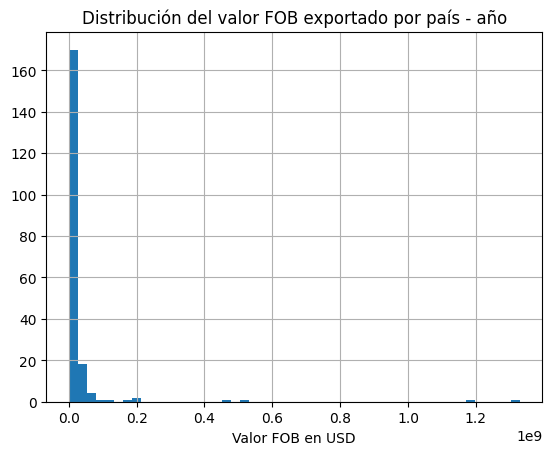

In [ ]:
#Histograma del valor exportado:

#Se busca observar cómo se distribuyen los montos en dólares exportados por cada país en
#cada año

df_expo_mundo['fobvalue'].hist(bins = 50)
plt.title('Distribución del valor FOB exportado por país - año')
plt.xlabel('Valor FOB en USD')
plt.show()

Text(0, 0.5, 'Valor FOB en USD')

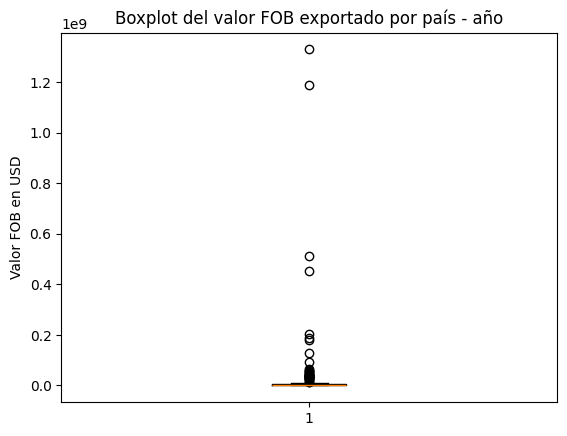

In [ ]:
#Boxplot del valor exportado

#Se busca observar si hay países con valores muy alejados del resto, es decir
#outliers

plt.boxplot(df_expo_mundo['fobvalue'])
plt.title('Boxplot del valor FOB exportado por país - año')
plt.ylabel('Valor FOB en USD')



**En este cuadro de texto analizar los resultados obtenidos hasta aca y dar una explicación de los mismos**

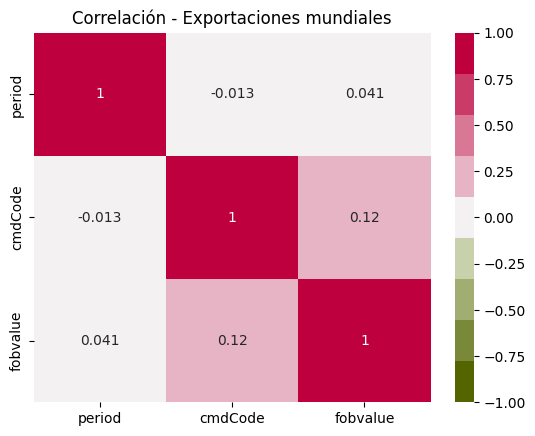

In [ ]:
#Correlación entre variables numéricas:

#Se observará rapidamente la relación entre las variables período (año),
#cmdCode (código del producto) y fobvalue (valor de alfalfa en dólares)

palette = sns.diverging_palette(100, 5, s=100, l=40, n=9) #paleta divergente que mejora la observación de la correlación
sns.heatmap(df_expo_mundo[['period', 'cmdCode','fobvalue']].corr(), annot=True, cmap=palette, vmin=-1, vmax=1)
plt.title('Correlación - Exportaciones mundiales')
plt.show()

En este cuadro de texto explicar los resultados observados de la correlación

###**b. Importaciones Mundiales**

In [ ]:
#Tipos de datos y cantidad de registros:
df_impo_mundo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   period        312 non-null    int64  
 1   reporterDesc  312 non-null    object 
 2   cmdCode       312 non-null    int64  
 3   cifvalue      302 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 9.9+ KB


In [ ]:
# Estadística descriptiva:
df_impo_mundo.describe()

,period,cmdCode,cifvalue
count,312.000000,312.000000,3.020000e+02
mean,2024.314103,121452.307692,1.397649e+07
std,0.464903,39.997527,7.064087e+07
min,2024.000000,121410.000000,6.000000e+00
25%,2024.000000,121410.000000,3.524204e+04
50%,2024.000000,121490.000000,5.600261e+05
75%,2025.000000,121490.000000,3.640470e+06
max,2025.000000,121490.000000,6.699853e+08


In [ ]:
#Valores faltantes
df_impo_mundo.isnull().sum()

,0
period,0
reporterDesc,0
cmdCode,0
cifvalue,10


In [ ]:
print('Cantidad de paises:', df_impo_mundo['reporterDesc'].nunique())
df_impo_mundo['cmdCode'].value_counts()

Cantidad de paises: 119


,count
cmdCode,
121490,165
121410,147


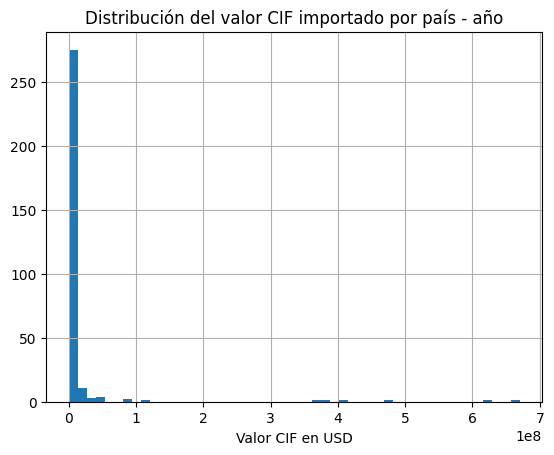

In [ ]:
#Histograma del valor importado
df_impo_mundo['cifvalue'].hist(bins = 50)
plt.title('Distribución del valor CIF importado por país - año')
plt.xlabel('Valor CIF en USD')
plt.show()

Text(0, 0.5, 'Valor CIF en USD')

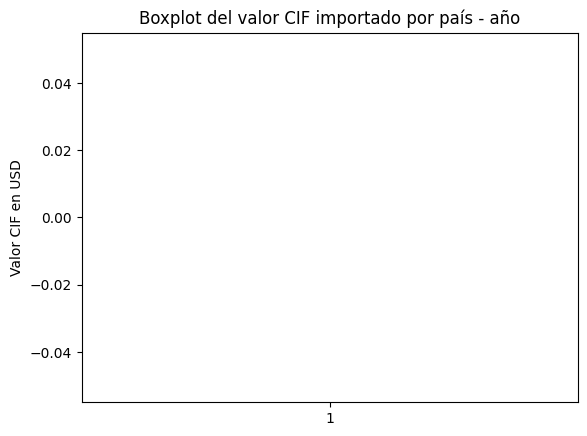

In [ ]:
#Boxplot del valor importado
plt.boxplot(df_impo_mundo['cifvalue'])
plt.title('Boxplot del valor CIF importado por país - año')
plt.ylabel('Valor CIF en USD')


Text(0, 0.5, 'Valor CIF en USD')

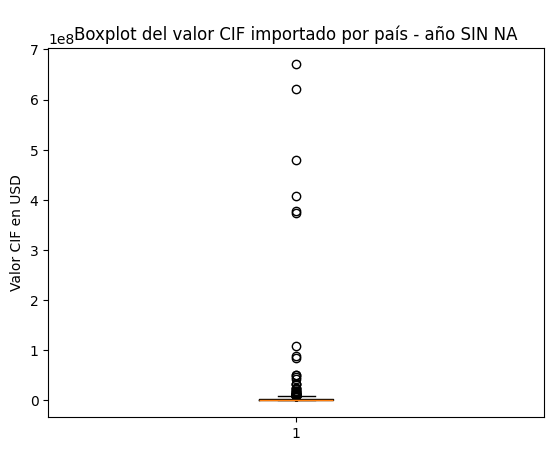

In [ ]:
#Boxplot sin valores nulos:

#Debido a que el conjunto de datos anteriores contenía valores nulos no pudo dibujarse
#el boxplot. Por esta razón se eliminarán a continuación dichos NA para poder
#observar la distribución:
plt.boxplot(df_impo_mundo['cifvalue'].dropna())
plt.title('Boxplot del valor CIF importado por país - año SIN NA')
plt.ylabel('Valor CIF en USD')

**Explicar en este cuadro los resultados observados hasta acá**

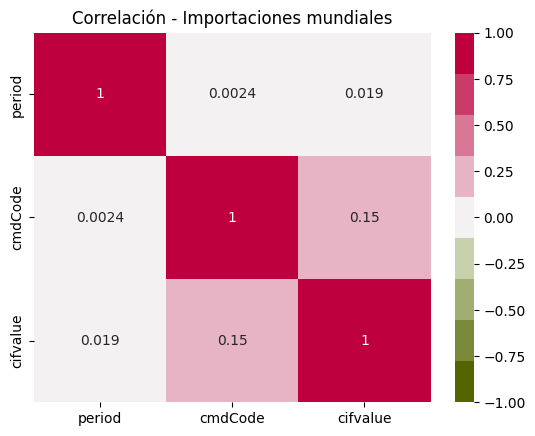

In [ ]:
#Correlación entre variables numéricas
sns.heatmap(df_impo_mundo[['period', 'cmdCode','cifvalue']].corr(), annot=True, cmap=palette, vmin=-1, vmax=1)
plt.title('Correlación - Importaciones mundiales')
plt.show()

**Explicar lo observado en la correlación**

###**c. Exportaciones Argentina

In [ ]:
#Tipos de datos y cantidad de registros:
df_expo_arg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2607 entries, 0 to 2606
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Fecha               2607 non-null   datetime64[ns]
 1   NCM-SIM             2607 non-null   object        
 2   Exportador          2607 non-null   object        
 3   Localidad           2607 non-null   object        
 4   Aduana              2607 non-null   object        
 5   Via Transporte      2607 non-null   object        
 6   País de Destino     2607 non-null   object        
 7   U$S FOB             2607 non-null   float64       
 8   Cantidad            2607 non-null   float64       
 9   Kgs. Netos          2607 non-null   float64       
 10  Condición de Venta  2607 non-null   object        
 11  ES CÓRDOBA?         2607 non-null   object        
 12  ES CLÚSTER?         2607 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(9)
memo

In [ ]:
#Estadística descriptiva de variables:
df_expo_arg.describe()

,Fecha,U$S FOB,Cantidad,Kgs. Netos
count,2607,2.607000e+03,2.607000e+03,2.607000e+03
mean,2025-02-15 11:40:56.616800768,4.382087e+04,2.603917e+03,1.130533e+05
min,2024-01-02 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2024-09-06 00:00:00,9.527500e+02,2.013000e+01,1.591500e+04
50%,2025-02-17 00:00:00,4.437000e+03,5.280000e+01,2.700000e+04
75%,2025-08-25 00:00:00,1.478400e+04,2.398900e+02,8.401000e+04
max,2025-12-30 00:00:00,1.225000e+06,1.800000e+06,2.500000e+06
std,NaN,1.189994e+05,4.630103e+04,2.456806e+05


In [ ]:
#Estadística descriptiva de variables tipo numéricas:
df_expo_arg[['U$S FOB', 'Kgs. Netos', 'Cantidad']].describe()

,U$S FOB,Kgs. Netos,Cantidad
count,2.607000e+03,2.607000e+03,2.607000e+03
mean,4.382087e+04,1.130533e+05,2.603917e+03
std,1.189994e+05,2.456806e+05,4.630103e+04
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.527500e+02,1.591500e+04,2.013000e+01
50%,4.437000e+03,2.700000e+04,5.280000e+01
75%,1.478400e+04,8.401000e+04,2.398900e+02
max,1.225000e+06,2.500000e+06,1.800000e+06


In [ ]:
#Valores faltantes:
df_expo_arg.isnull().sum()

,0
Fecha,0
NCM-SIM,0
Exportador,0
Localidad,0
Aduana,0
Via Transporte,0
País de Destino,0
U$S FOB,0
Cantidad,0
Kgs. Netos,0


In [ ]:
#Filas duplicadas
#Este punto se realiza para determinar si hay operaciones cargadas dos veces
#por error. Esto se puede realizar ya que son datos mucho más detallados

print('Filas duplicadas:', df_expo_arg.duplicated().sum())


Filas duplicadas: 340


In [ ]:
#Cantidad de categorías por variable:

#Es necesario visualizar cada categoría de cada variable para comprender
#claramente qué significa cada una y luego interpretar correctamente los resultados
#sobre las mismas

for col in ['Exportador', 'Localidad','Aduana','Via Transporte','País de Destino','Condición de Venta']:
  print(col, '->', df_expo_arg[col].nunique(),'Valores únicos')

Exportador -> 44 Valores únicos
Localidad -> 29 Valores únicos
Aduana -> 17 Valores únicos
Via Transporte -> 4 Valores únicos
País de Destino -> 29 Valores únicos
Condición de Venta -> 7 Valores únicos


Debido a que hay variables con pocas categorías, a continuación se detallará cada una de ellas, ya que serán clave a posterior para analizar los resultados de correlación y regresión lineal

In [ ]:
#Vía de Transporte:
df_expo_arg['Via Transporte'].value_counts()

,count
Via Transporte,
CAMION,2538
FERROCARRIL,51
ACUATICA,17
AVION,1


In [ ]:
#Condición de venta:
df_expo_arg['Condición de Venta'].value_counts()

,count
Condición de Venta,
FCA,1673
FOB,898
CFR,16
CPT,10
CIF,4
CIP,4
EXW,2


Claramente es necesario explicar que significan cada una de estas categorías para conocer correctamente el df

In [ ]:
#Es Córdoba?
df_expo_arg['ES CÓRDOBA?'].value_counts()

,count
ES CÓRDOBA?,
SI,1379
NO,1228


In [ ]:
#Es cluster?
df_expo_arg['ES CLÚSTER?'].value_counts()

,count
ES CLÚSTER?,
NO,1787
SI,820


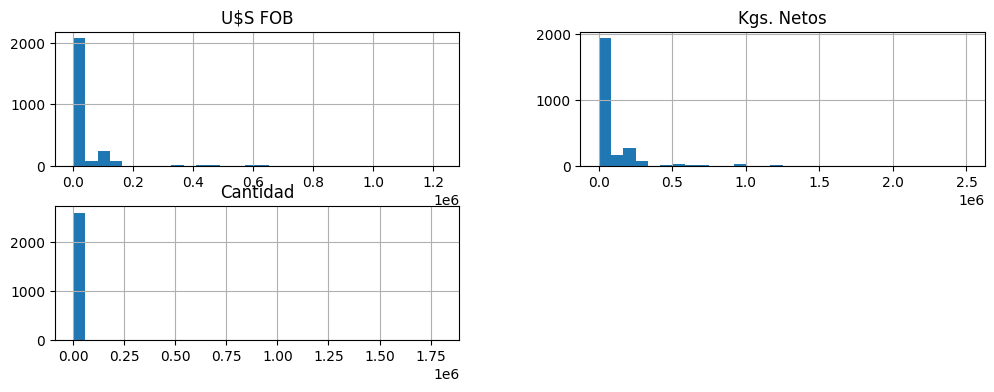

In [ ]:
#Histogramas de las variables numéricas:
df_expo_arg[['U$S FOB', 'Kgs. Netos','Cantidad']].hist(bins=30,figsize=(12,4))
plt.show()


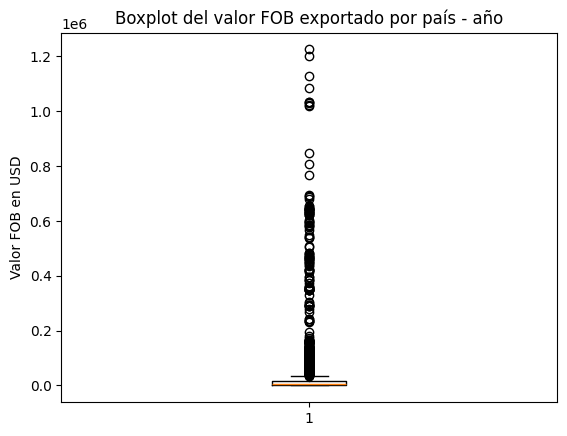

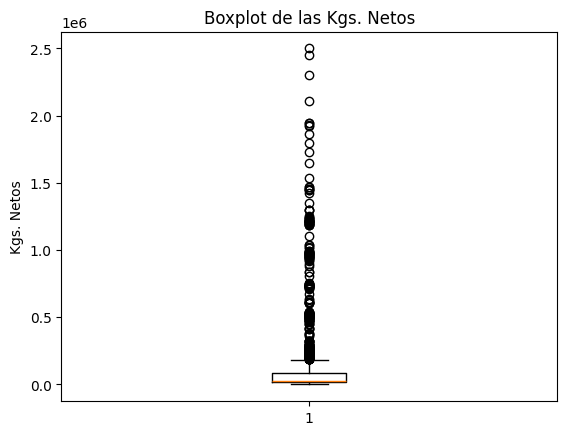

In [ ]:
#Boxplot de variables numéricas

plt.boxplot(df_expo_arg['U$S FOB'])
plt.title('Boxplot del valor FOB exportado por país - año')
plt.ylabel('Valor FOB en USD')
plt.show()

plt.boxplot(df_expo_arg['Kgs. Netos'])
plt.title('Boxplot de las Kgs. Netos')
plt.ylabel('Kgs. Netos')
plt.show()

Es necesario hacer una mejor interpretación pero basicamente se ve aplastado porque aún no se ha realizado un preprocesamiento de los datos.

Estos resultados nos indican que estamos mezclando envíos muy grandes, con pesos muy altos y envíos más pequeños, provocando muchos outliers.

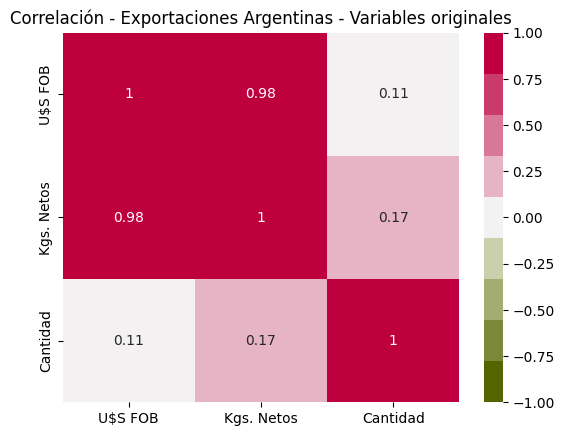

In [ ]:
#Correlación entre variables numéricas originales
#Esta correlación se realizó unicamente con los datos originales,
#sin procesar
sns.heatmap(df_expo_arg[['U$S FOB', 'Kgs. Netos','Cantidad']].corr(), annot=True, cmap=palette, vmin=-1, vmax=1)
plt.title('Correlación - Exportaciones Argentinas - Variables originales')
plt.show()

###**d. Importaciones detalladas por Empresa

In [ ]:
#Tipos de datos y cantidad de registros
df_impo_empresa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1307 entries, 0 to 1306
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   NCM                 1307 non-null   float64
 1   AÑO                 1307 non-null   int64  
 2   País de Empresa     1307 non-null   object 
 3   Valor U$S           1307 non-null   float64
 4   Kilos               1307 non-null   float64
 5   Socios Comerciales  1307 non-null   object 
dtypes: float64(3), int64(1), object(2)
memory usage: 61.4+ KB


In [ ]:
#Estadísticas descriptivas
df_impo_empresa.describe()

,NCM,AÑO,Valor U$S,Kilos
count,1307.000000,1307.000000,1.307000e+03,1.307000e+03
mean,1214.519281,2024.540168,1.421813e+05,1.565580e+05
std,0.399688,0.498575,1.870696e+06,7.293032e+05
min,1214.100000,2024.000000,0.000000e+00,0.000000e+00
25%,1214.100000,2024.000000,1.037110e+03,6.000000e+00
50%,1214.900000,2025.000000,7.080000e+03,1.188400e+04
75%,1214.900000,2025.000000,3.521629e+04,7.949085e+04
max,1214.900000,2025.000000,6.508686e+07,1.961591e+07


In [ ]:
#Valores faltantes
df_impo_empresa.isnull().sum()

,0
NCM,0
AÑO,0
País de Empresa,0
Valor U$S,0
Kilos,0
Socios Comerciales,0


In [ ]:
print('Cantidad de países importadores:', df_impo_empresa['País de Empresa'].nunique())
df_impo_empresa['AÑO'].value_counts()

Cantidad de países importadores: 62


,count
AÑO,
2025,706
2024,601


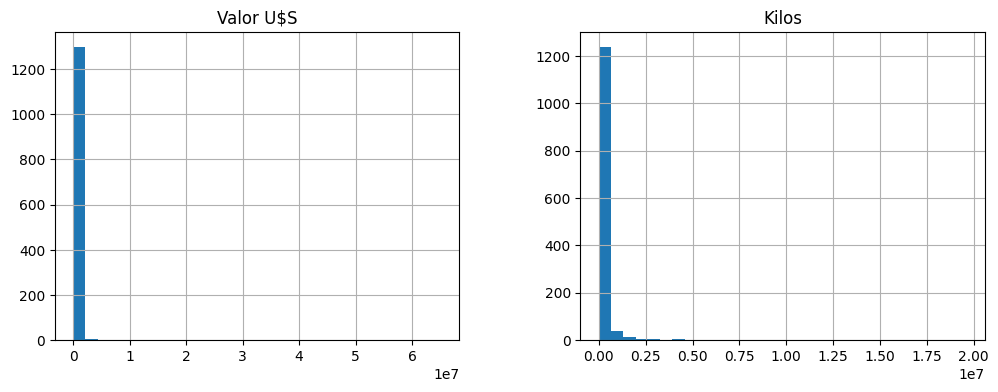

In [ ]:
#Histograma de variables numéricas
df_impo_empresa[['Valor U$S', 'Kilos']].hist(bins=30, figsize=(12,4))
plt.show()

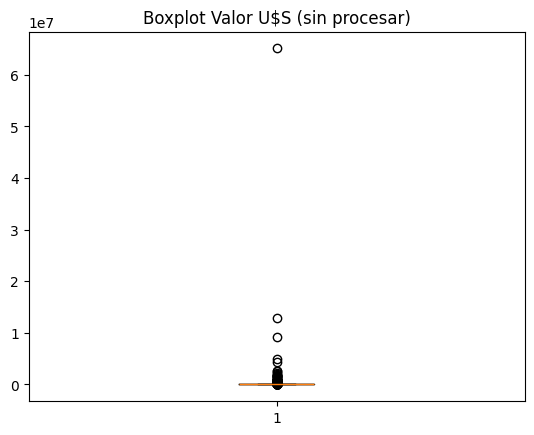

In [ ]:
#Boxplot del valor importado
plt.boxplot(df_impo_empresa['Valor U$S'])
plt.title('Boxplot Valor U$S (sin procesar)')
plt.show()

**Usar este recuadro para explicar todo lo observado hasta aca de este df**

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

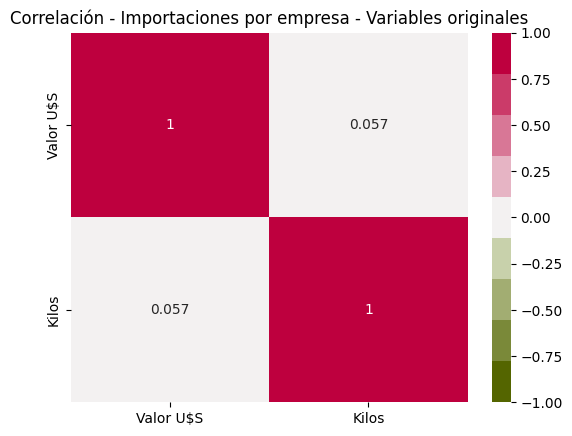

In [ ]:
#Correlación entre variables numéricas

sns.heatmap(df_impo_empresa[['Valor U$S', 'Kilos']].corr(), annot=True,
            cmap=palette, vmin=-1, vmax=1)
plt.title('Correlación - Importaciones por empresa - Variables originales')
plt

**Escribir en este cuadro conclusiones de la correlación**

### 4. Análisis Exporatorio el MERCADO MUNDIAL**

A continuación se realizará un análisis a nivel del mercado con énfasis en el posicionamiento de Argentina en el mismo, para responder las siguientes preguntas:

* 4.1. ¿Qué lugar ocupa Argentina entre los exportadores?
* 4.2. ¿Cómo exporta Argentina? ¿Qué provincias exportan? ¿Qué aduanas participan?
* 4.3. ¿Qué empresas lideran? ¿Está concentrado en pocas empresas?
* 4.4. ¿Hacia dónde exporta Argentina? ¿Cuántos mercados atiende?
* 4.5. ¿Qué porcentaje representan los principales compradores? ¿Argentina depende de pocos compradores?
* 4.6.¿Los principales compradores mundiales son clientes de Argentina? ¿Hay mercados grandes donde Argentina casi no participa?
* 4.7. ¿Qué mercados representan oportundiades comerciales para Argentina?

Las variables a utilizar serán las originales, aún sin el preprocesamiento que se aplicará para realizar los modelos de regresión lineal, ya que para este punto aún no son necesarios.

El objetivo de este Análisis Exploratorio del Mercado es identificar en qué puntos el modelo de regresión lineal podría beneficiar a Argentina
